In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# magic autoreload
%load_ext autoreload
%autoreload 2
from utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
datadir = "data"
df_dict = {}
for f in os.listdir(datadir):
    df = pd.read_csv(os.path.join(datadir, f))
    df.columns = [c.lower() for c in df.columns]
    df.dropna(how="all", inplace=True)
    df = df.loc[df.date!="NaN-NaN-NaN NaN:NaN:NaN"]
    df.set_index("date", inplace=True)
    # Strip whitespace from index
    df.index = df.index.str.strip()
    try:
        df.index = pd.to_datetime(df.index, format="%Y-%m-%d %H:%M:%S")
    except ValueError:
        try:
            df.index = pd.to_datetime(df.index, format="%d/%m/%Y %H:%M")
        except ValueError:
            # If both fail, use infer_datetime_format
            df.index = pd.to_datetime(df.index, infer_datetime_format=True)
    df = df.squeeze()
    if isinstance(df, pd.DataFrame):
        df = df["wl_corr"]
    df.dropna(inplace=True)
    df.name = f.split(".")[0].lower()
    df_dict[df.name] = df
    print(f"{f}: {df.shape}")
data = pd.DataFrame(df_dict)

ERAMAG01W.csv: (321564,)
ERAMAG05.csv: (386040,)
ERAMAG05.csv: (386040,)
ERAMAG03.csv: (338792,)
ERAMAG03.csv: (338792,)
ERAMAG09W.csv: (317430,)
ERAMAG09W.csv: (317430,)
G8210009.csv: (310937,)
G8210009.csv: (310937,)
ERAMCUS.csv: (291782,)
ERAMCUS.csv: (291782,)


In [10]:
#data.index = pd.to_datetime(data.index, format="mixed")
data = data.sort_index()

In [11]:
data = data.drop(columns=["eramag03","eramag05","eramcus","eramag09w"])

<Axes: xlabel='date'>

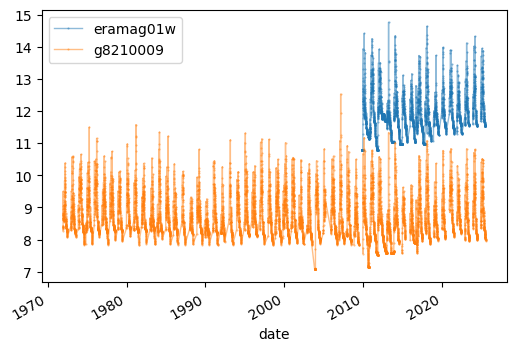

In [71]:
data_day = data.resample("D").mean().copy()
data_day.dropna(how="all", inplace=True)
data_day.plot(figsize=(6, 4), marker=".", markersize=1,lw=1,alpha=0.5)

In [72]:
X = data_day.values.copy()
mask=None

# scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()



X_imputed = iterative_svd_impute(X, rank=1, mask=mask,)#scaler=scaler)
#print("Imputed matrix:\n", X_imputed)

dfp = pd.DataFrame(X_imputed, index=data_day.index, columns=data_day.columns)



In [73]:
# add rows for missing dates
new_index = pd.date_range(start=data_day.index.min(), end=data_day.index.max(), freq='D')
dfp = pd.DataFrame(index=new_index, columns=data_day.columns)
dfp.loc[data_day.index,:] = X_imputed


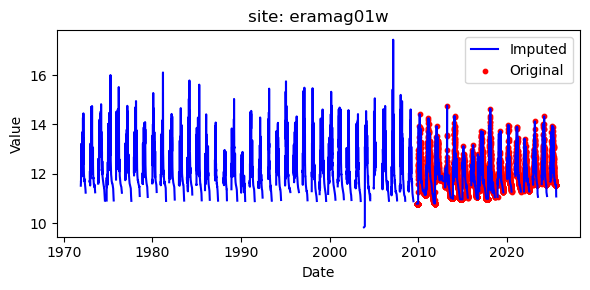

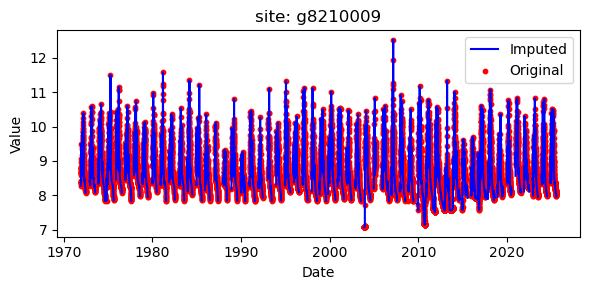

In [74]:
for col in dfp.columns:
    fig,ax = plt.subplots(figsize=(6,3))
    ax.plot(dfp.index, dfp[col], label='Imputed', color='blue')
    ax.scatter(data_day.index, data_day[col], label='Original', color='red', s=10)
    ax.set_title(f"site: {col}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.legend()
    fig.tight_layout()
    plt.show();